# 07 - Predictive Modeling

## Customer Intelligence Platform

---
This notebook trains 5 classification models, compares their performance,
and performs threshold optimization to maximize business value.

### Models
1. **Logistic Regression** (interpretable baseline)
2. **Random Forest** (tree-based baseline)
3. **XGBoost** (gradient boosting)
4. **LightGBM** (fast gradient boosting)
5. **CatBoost** (categorical-native boosting)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib
%matplotlib inline

from src.load_data import load_features
from src.preprocessing import prepare_data, encode_features, split_data, scale_features
from src.train import get_models, train_model, train_all_models, save_models
# from src.evaluate import (
#     compute_metrics,
#     plot_confusion_matrix,
#     plot_roc_curves,
#     plot_precision_recall_curves,
#     plot_threshold_analysis,
#     optimize_threshold,
#     model_comparison_table,
# )
from src.evaluate import *
from src.config import TARGET, BEST_MODEL_FILE, MODELS_DIR

In [2]:
# load feature enriched dataset
df = load_features()

✅ Loaded features: 7,043 rows × 35 cols


## Preprocessing

---

In [3]:
X_train, X_test, y_train, y_test, scaler, feature_names = prepare_data(df)
print(f"\nFeature names ({len(feature_names)}):")
for i, f in enumerate(feature_names[:10]):
    print(f"  {i+1}. {f}")
print(f"  ... and {len(feature_names)-10} more")


[PREPROCESSING PIPELINE]
   Encoded features: 50 columns
[INFO] Train set: 5,634 samples
[INFO] Test set:  1,409 samples
[INFO] Train churn rate: 26.54%
[INFO] Test churn rate:  26.54%
   Scaled numerical features
   Final feature count: 49

Feature names (49):
  1. Gender
  2. Senior Citizen
  3. Partner
  4. Dependents
  5. Tenure Months
  6. Phone Service
  7. Paperless Billing
  8. Monthly Charges
  9. Total Charges
  10. is_new_customer
  ... and 39 more


## Train All Models

---

In [4]:
results, best_name, best_model = train_all_models(X_train, X_test, y_train, y_test)


[MODEL TRAINING]

   Training Logistic Regression...
   Logistic Regression: ROC-AUC = 0.8538, F1 = 0.5932
[TIME] train_model completed in 0.05s

   Training Random Forest...
   Random Forest: ROC-AUC = 0.8520, F1 = 0.6482
[TIME] train_model completed in 0.77s

   Training XGBoost...
   XGBoost: ROC-AUC = 0.8305, F1 = 0.5963
[TIME] train_model completed in 0.49s

   Training LightGBM...
   LightGBM: ROC-AUC = 0.8322, F1 = 0.6010
[TIME] train_model completed in 0.25s

   Training CatBoost...
   CatBoost: ROC-AUC = 0.8403, F1 = 0.6170
[TIME] train_model completed in 2.87s

   ** Best Model: Logistic Regression (ROC-AUC = 0.8538) **


## Model Comparison

---

In [5]:
comparison = model_comparison_table(results)
comparison

,Model,ROC-AUC,F1
0,Logistic Regression,0.853796,0.593245
1,Random Forest,0.851957,0.648230
2,CatBoost,0.840334,0.617047
3,LightGBM,0.832158,0.600973
4,XGBoost,0.830511,0.596273


## ROC Curves

----

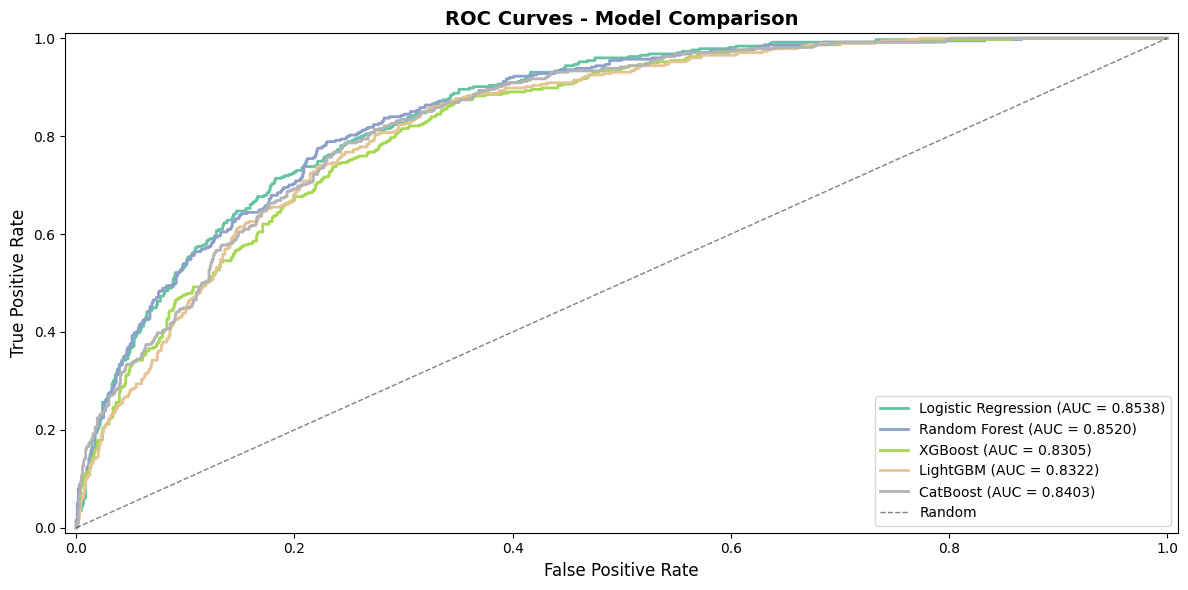

In [6]:
models_dict = {r["name"]: r["model"] for r in results}
fig = plot_roc_curves(models_dict, X_test, y_test)
plt.show()

## Precision-Recall Curves

---

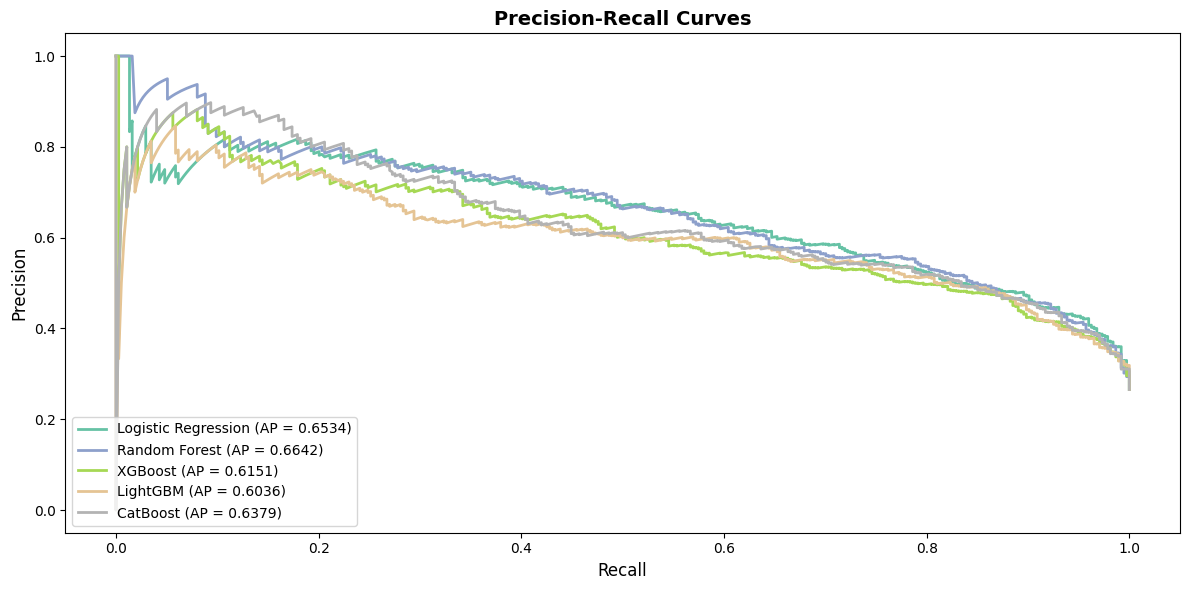

In [7]:
fig = plot_precision_recall_curves(models_dict, X_test, y_test)
plt.show()

## Best Model - Detailed Evaluation

---

In [8]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print(f"Best Model: {best_name}")
print(f"\n{'='*40}")
metrics = compute_metrics(y_test, y_pred, y_prob)
for k, v in metrics.items():
    print(f"  {k}: {v}")

Best Model: Logistic Regression

  accuracy: 0.8034
  precision: 0.658
  recall: 0.5401
  f1: 0.5932
  roc_auc: 0.8538
  pr_auc: 0.6534


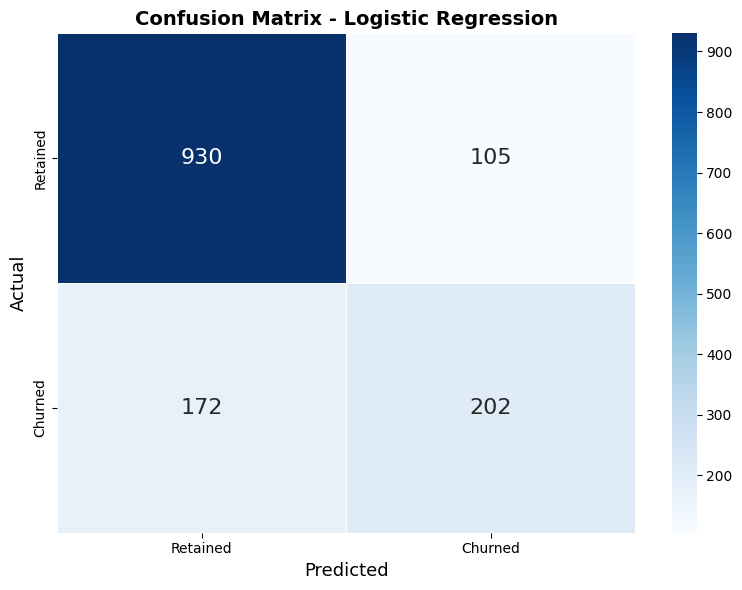

In [9]:
fig = plot_confusion_matrix(y_test, y_pred, title=f"Confusion Matrix - {best_name}")
plt.show()

## Threshold Optimization

---
Through the default threshold used is generally 0.5 but here We optimize it to maximize F1 score.

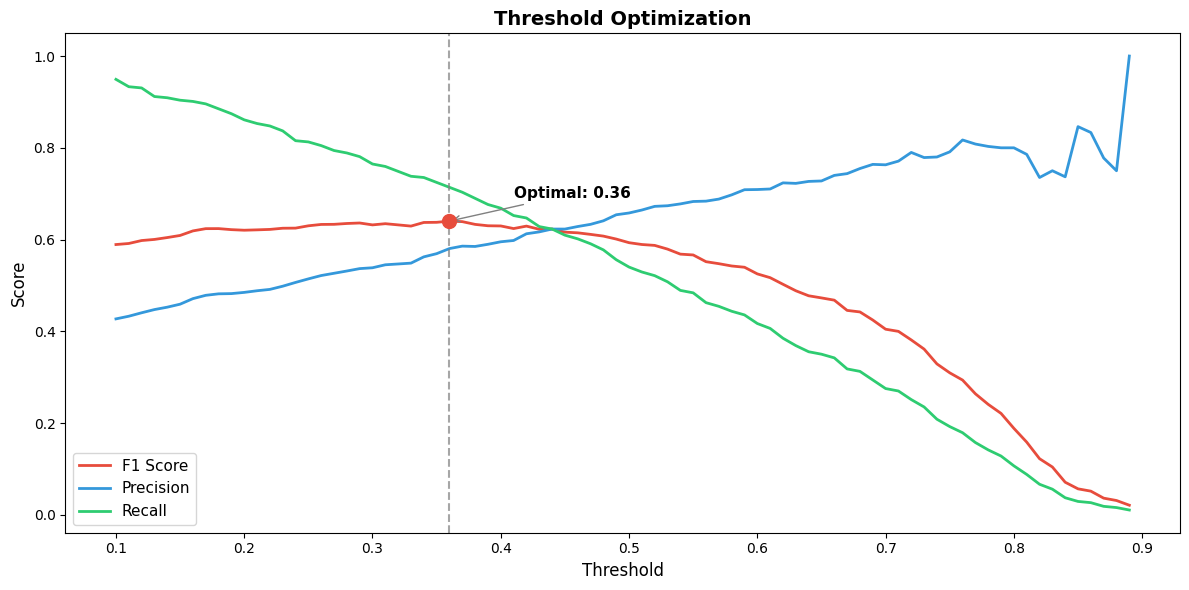

In [10]:
fig = plot_threshold_analysis(y_test, y_prob)
plt.show()

In [11]:
opt_result = optimize_threshold(y_test, y_prob, metric="f1")
print(f"Optimal Threshold: {opt_result['optimal_threshold']}")
print(f"Best F1: {opt_result['best_score']}")
print(f"\nMetrics at optimal threshold:")
for k, v in opt_result["metrics_at_threshold"].items():
    print(f"  {k}: {v}")

Optimal Threshold: 0.36
Best F1: 0.6403

Metrics at optimal threshold:
  accuracy: 0.7871
  precision: 0.5804
  recall: 0.7139
  f1: 0.6403
  roc_auc: 0.8538
  pr_auc: 0.6534


### Threshold Analysis

---
The optimal threshold is lower than 0.5, which makes sense for churn prediction:
- **Lower threshold** = catch more churners (higher recall)
- **Higher threshold** = fewer false alarms (higher precision)
- For retention campaigns, we generally prefer **higher recall** (catch more at-risk customers)

In [ ]:
save_models(results, best_name, best_model)
# Also save preprocessing artifacts
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
import json
with open(MODELS_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f)
X_test.to_csv(MODELS_DIR / "X_test.csv", index=False)
y_test.to_csv(MODELS_DIR / "y_test.csv", index=False)
print("All models and artifacts saved.")

[OK] Saved best model -> best_model.joblib
[OK] Saved metrics -> metrics.json
All models and artifacts saved.


### Key Decisions
1. **Best model selected by ROC-AUC** (overall discrimination ability)
2. **Threshold optimized for F1** (balance precision and recall)
3. **All 5 models saved** for comparison and ensemble potential
4. **Class imbalance handled** via class weights and threshold optimization